In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

excel_file = pd.ExcelFile('../data/Data.xlsx')
print(excel_file.sheet_names)

['Restaurants', 'Charities', 'Food', 'Deals']


In [2]:
restaurants = pd.read_excel(excel_file, sheet_name='Restaurants')
food = pd.read_excel(excel_file, sheet_name='Food')
charities = pd.read_excel(excel_file, sheet_name='Charities')
deals = pd.read_excel(excel_file, sheet_name='Deals')

In [3]:
print(restaurants.head().to_string())
restaurants.info()
restaurants.isnull().sum()

   Restaurant_ID Restaurant_Name         Area       Category  Avg_Meal_Price  User_Rating   Latitude  Longitude
0              1       Pizza Hut    Nasr City         Bakery             786          4.2  30.055021  31.334979
1              2             KFC        Maadi      Fast Food             494          4.4  29.963775  31.265048
2              3           Crave        Dokki  Casual Dining             158          4.0  30.038418  31.203253
3              4       McDonalds  Mohandessin         Bakery             191          4.7  30.051898  31.203368
4              5  Buffalo Burger        Maadi         Bakery             180          4.0  29.958295  31.250455
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Restaurant_ID    120 non-null    int64  
 1   Restaurant_Name  120 non-null    object 
 2   Area             120 non-null    ob

Restaurant_ID      0
Restaurant_Name    0
Area               0
Category           0
Avg_Meal_Price     0
User_Rating        0
Latitude           0
Longitude          0
dtype: int64

In [4]:
print(charities.head().to_string())
charities.info()
charities.isnull().sum()

   Charity_ID         Charity_Name         Area  Daily_Need_Meals  Vehicles  User_Rating   Latitude  Longitude
0           1       Misr El Kheir        Ramses               308         3          4.8  30.063673  31.268545
1           2              Mersal       Zamalek               491         1          4.1  30.059282  31.227138
2           3              Mersal         Dokki                87         1          4.4  30.034172  31.204456
3           4       Misr El Kheir       Tagamoa               205         8          4.4  30.013891  31.489007
4           5  Egyptian Food Bank   Mohandessin               416         8          4.4  30.048293  31.192568
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Charity_ID        60 non-null     int64  
 1   Charity_Name      60 non-null     object 
 2   Area              60 non-null     objec

Charity_ID          0
Charity_Name        0
Area                0
Daily_Need_Meals    0
Vehicles            0
User_Rating         0
Latitude            0
Longitude           0
dtype: int64

In [5]:
print(food.head().to_string())
food.info()
food.isnull().sum()

   Food_ID  Restaurant_ID Food_Type  Quantity_KG  Original_Price  Discounted_Price         Upload_Time         Expiry_Time  Expiry_Duration_Hours     Status
0        1             58    Bakery         22.0             717               190 2026-04-28 23:14:00 2026-04-29 07:14:00                      8  Available
1        2            112    Bakery         27.1             350                72 2026-04-28 20:26:00 2026-04-29 01:26:00                      5  Available
2        3             17    Canned          7.8            1849               537 2026-04-28 19:27:00 2026-04-29 00:27:00                      5  Available
3        4             37    Canned         27.5            1215               252 2026-04-28 20:32:00 2026-04-29 00:32:00                      4  Available
4        5             84    Bakery         23.9            2432               490 2026-04-28 22:00:00 2026-04-29 03:00:00                      5  Available
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entr

Food_ID                  0
Restaurant_ID            0
Food_Type                0
Quantity_KG              0
Original_Price           0
Discounted_Price         0
Upload_Time              0
Expiry_Time              0
Expiry_Duration_Hours    0
Status                   0
dtype: int64

In [6]:
print(deals.head().to_string())
deals.info()
deals.isnull().sum

   Deal_ID  Food_ID  Charity_ID  Distance_KM  AI_Score  Decision
0        1      239          32        11.82      42.6  Rejected
1        2      144           8        30.26       0.0  Rejected
2        3      208          57        15.49      15.3  Rejected
3        4      304          15         3.09      91.8  Accepted
4        5       76          43        25.74       0.0  Rejected
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Deal_ID      550 non-null    int64  
 1   Food_ID      550 non-null    int64  
 2   Charity_ID   550 non-null    int64  
 3   Distance_KM  550 non-null    float64
 4   AI_Score     550 non-null    float64
 5   Decision     550 non-null    object 
dtypes: float64(2), int64(3), object(1)
memory usage: 25.9+ KB


<bound method DataFrame.sum of      Deal_ID  Food_ID  Charity_ID  Distance_KM  AI_Score  Decision
0      False    False       False        False     False     False
1      False    False       False        False     False     False
2      False    False       False        False     False     False
3      False    False       False        False     False     False
4      False    False       False        False     False     False
..       ...      ...         ...          ...       ...       ...
545    False    False       False        False     False     False
546    False    False       False        False     False     False
547    False    False       False        False     False     False
548    False    False       False        False     False     False
549    False    False       False        False     False     False

[550 rows x 6 columns]>

In [7]:
food['Discount_Amount'] = food['Original_Price'] - food['Discounted_Price']

food['Discount_Percentage'] = (
    food['Discount_Amount'] / food['Original_Price']
) * 100

food['Upload_Hour'] = food['Upload_Time'].dt.hour
food['Upload_Day'] = food['Upload_Time'].dt.day_name()

In [8]:
total_food = food['Quantity_KG'].sum()
print("Total Food Available:", total_food)

Total Food Available: 5610.400000000001


In [9]:
avg_discount = food['Discount_Percentage'].mean()
print("Average Discount %:", avg_discount)

Average Discount %: 75.07226416890063


In [10]:
avg_expiry = food['Expiry_Duration_Hours'].mean()
print("Average Expiry Hours:", avg_expiry)

Average Expiry Hours: 4.8342857142857145


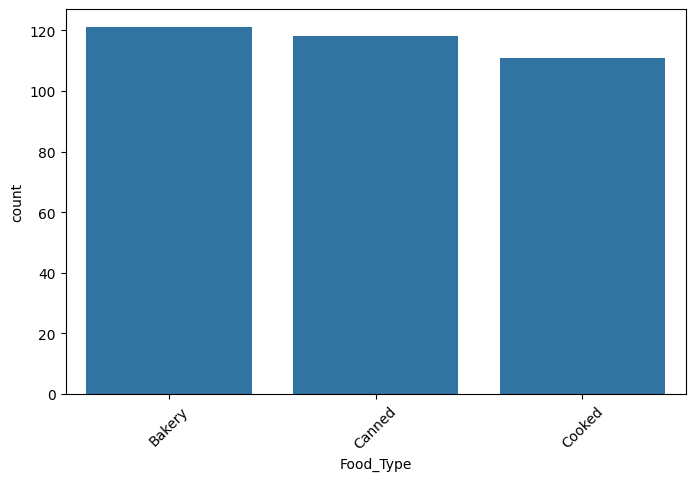

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(data=food, x='Food_Type')
plt.xticks(rotation=45)
plt.show()

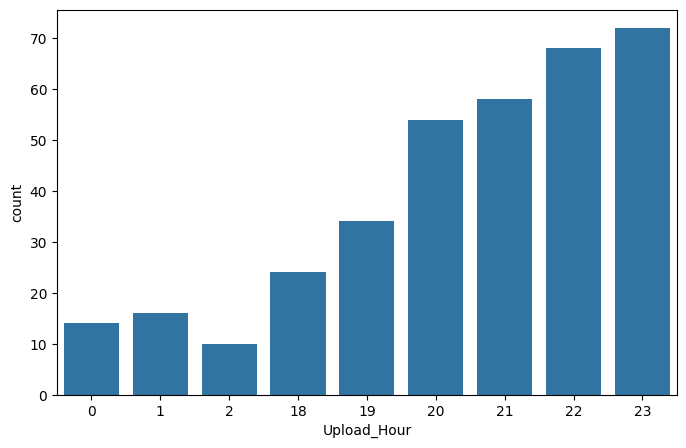

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(data=food, x='Upload_Hour')
plt.show()

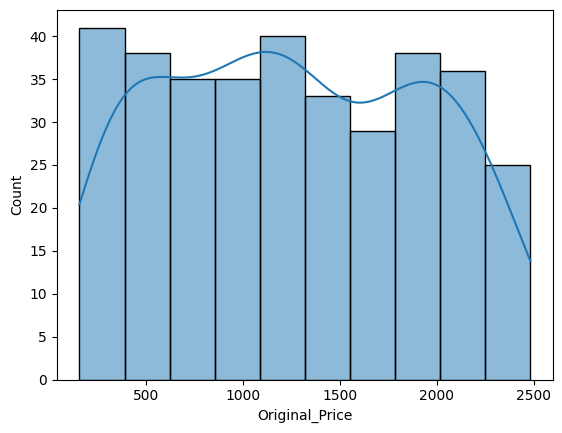

In [13]:
sns.histplot(food['Original_Price'], kde=True)
plt.show()

In [14]:
deals['Decision_Binary'] = deals['Decision'].map({
    'Accepted':1,
    'Rejected':0
})

In [15]:
print("Acceptance Rate:", deals['Decision_Binary'].mean()*100)

Acceptance Rate: 46.0


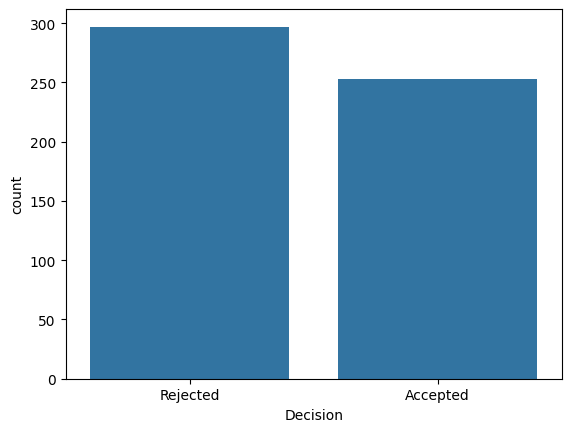

In [16]:
sns.countplot(data=deals, x='Decision')
plt.show()

In [17]:
merged = deals.merge(food, on='Food_ID')
merged = merged.merge(charities, on='Charity_ID')

In [18]:
merged.head()

,Deal_ID,Food_ID,Charity_ID,Distance_KM,AI_Score,Decision,Decision_Binary,Restaurant_ID,Food_Type,Quantity_KG,...,Discount_Percentage,Upload_Hour,Upload_Day,Charity_Name,Area,Daily_Need_Meals,Vehicles,User_Rating,Latitude,Longitude
0,1,239,32,11.82,42.6,Rejected,0,97,Bakery,27.0,...,78.592375,19,Tuesday,Mersal,Maadi,215,4,4.6,29.955464,31.263190
1,2,144,8,30.26,0.0,Rejected,0,81,Cooked,26.5,...,75.753715,23,Tuesday,Hayah Karima,Zamalek,107,3,5.0,30.052601,31.219234
2,3,208,57,15.49,15.3,Rejected,0,88,Bakery,16.8,...,73.425499,23,Tuesday,Mersal,Nasr City,207,5,4.5,30.068625,31.329980
3,4,304,15,3.09,91.8,Accepted,1,65,Canned,14.3,...,79.353234,21,Tuesday,Misr El Kheir,Dokki,238,4,5.0,30.036027,31.208120
4,5,76,43,25.74,0.0,Rejected,0,111,Bakery,3.3,...,73.723229,19,Tuesday,Ahl Masr,Ramses,278,4,4.1,30.066996,31.264265


In [19]:
X = merged[['Distance_KM','Quantity_KG','Expiry_Duration_Hours','Daily_Need_Meals']]
y = merged['Decision_Binary']

In [20]:
print(merged.shape)
print(merged.columns)

(550, 27)
Index(['Deal_ID', 'Food_ID', 'Charity_ID', 'Distance_KM', 'AI_Score',
       'Decision', 'Decision_Binary', 'Restaurant_ID', 'Food_Type',
       'Quantity_KG', 'Original_Price', 'Discounted_Price', 'Upload_Time',
       'Expiry_Time', 'Expiry_Duration_Hours', 'Status', 'Discount_Amount',
       'Discount_Percentage', 'Upload_Hour', 'Upload_Day', 'Charity_Name',
       'Area', 'Daily_Need_Meals', 'Vehicles', 'User_Rating', 'Latitude',
       'Longitude'],
      dtype='object')


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
y_pred = model.predict(X_test)

In [24]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9363636363636364
              precision    recall  f1-score   support

           0       0.97      0.92      0.94        63
           1       0.90      0.96      0.93        47

    accuracy                           0.94       110
   macro avg       0.93      0.94      0.94       110
weighted avg       0.94      0.94      0.94       110



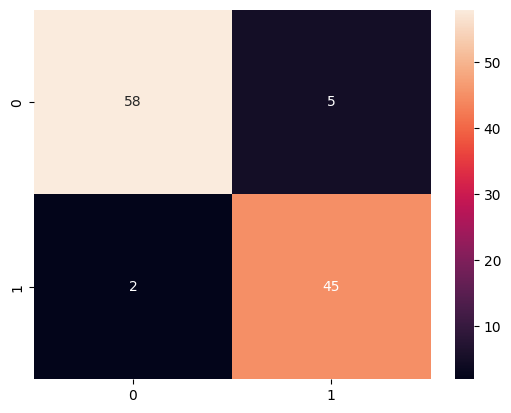

In [25]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.show()

In [26]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance)

                 Feature  Importance
0            Distance_KM    0.889410
1            Quantity_KG    0.050574
3       Daily_Need_Meals    0.043755
2  Expiry_Duration_Hours    0.016261


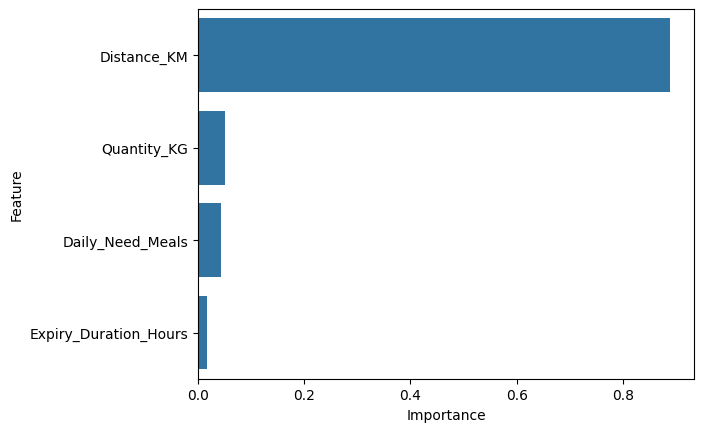

In [27]:
sns.barplot(data=importance, x='Importance', y='Feature')
plt.show()

In [28]:
food_full = food.merge(restaurants, on='Restaurant_ID')

In [29]:
def calculate_score(food_row, charity_row):

    food_lat = food_row['Latitude']
    food_lon = food_row['Longitude']

    charity_lat = charity_row['Latitude']
    charity_lon = charity_row['Longitude']

    distance = ((food_lat - charity_lat)**2 + (food_lon - charity_lon)**2) ** 0.5

    distance_score = 1 / (distance + 0.01)

    need_score = charity_row['Daily_Need_Meals'] / 100
    urgency = 1 / (food_row['Expiry_Duration_Hours'] + 1)
    rating_score = charity_row['User_Rating'] / 5

    return (
        0.4 * distance_score +
        0.3 * need_score +
        0.2 * urgency +
        0.1 * rating_score
    )

In [30]:
def get_top_charities(food_row, charities_df, top_n=3):
    scores = []

    for _, charity in charities_df.iterrows():
        score = calculate_score(food_row, charity)
        scores.append((charity['Charity_ID'], charity['Charity_Name'], score))

    scores = sorted(scores, key=lambda x: x[2], reverse=True)

    return scores[:top_n]

In [31]:
def pretty_print(top_list):
    for i, c in enumerate(top_list, 1):
        print(f"""
Rank {i}
Charity Name: {c[1]}
Charity ID: {c[0]}
AI Score: {round(c[2], 2)}
-----------------------
""")

In [32]:
food_sample = food_full.iloc[0]

top = get_top_charities(food_sample, charities)

pretty_print(top)


Rank 1
Charity Name: Hayah Karima 
Charity ID: 23
AI Score: 37.31
-----------------------


Rank 2
Charity Name: Misr El Kheir 
Charity ID: 7
AI Score: 28.3
-----------------------


Rank 3
Charity Name: Hayah Karima 
Charity ID: 8
AI Score: 23.31
-----------------------



In [33]:
def smart_top_charities(food_row, charities_df):
    filtered = []

    for _, charity in charities_df.iterrows():
        X_input = [[
            3,  # distance placeholder
            food_row['Quantity_KG'],
            food_row['Expiry_Duration_Hours'],
            charity['Daily_Need_Meals']
        ]]

        pred = model.predict(X_input)[0]

        if pred == 1:
            score = calculate_score(food_row, charity)
            filtered.append((charity['Charity_Name'], score))

    return sorted(filtered, key=lambda x: x[1], reverse=True)[:3]

In [34]:
import joblib
joblib.dump(model, '../models/matching_model.pkl')

['../models/matching_model.pkl']

In [35]:
from fastapi import FastAPI
import nest_asyncio
import uvicorn

In [36]:
model = joblib.load("../models/matching_model.pkl")

food_full = food.merge(restaurants, on='Restaurant_ID')

In [37]:
app = FastAPI()

In [38]:
@app.post("/recommend")
def recommend(food_id: int):

    food_row = food_full[food_full["Food_ID"] == food_id].iloc[0]

    top = get_top_charities(food_row, charities)

    return {
        "food_id": int(food_id),
        "top_charities": top
    }

In [ ]:
from pyngrok import ngrok
import uvicorn
from fastapi import FastAPI

app = FastAPI()

@app.post("/recommend")
async def recommend(data: dict):
    return {"message": "Success", "food_id": data.get("food_id")}

# ngrok.set_auth_token("")
public_url = ngrok.connect(8000)
print("Puplic Link :", public_url)

config = uvicorn.Config(app, host="0.0.0.0", port=8000)
server = uvicorn.Server(config)

await server.serve()